# Notebook 3 — Modelado Analítico: Rendimiento Académico y Permanencia
**Proyecto:** Academic Performance, Course Load, and Student Persistence  
**Institución:** Instituto Tecnológico Metropolitano (ITM)  

---
## Objetivo
Analizar la relación entre rendimiento académico, carga académica y permanencia
estudiantil mediante:

1. **Heatmaps** por semestre: distribución conjunta de materias matriculadas y aprobadas (Fig. 1)
2. **Regresión logística**: tasa de aprobación como predictor de permanencia (Fig. 2)
3. **Análisis de correlación individual**: perfiles de respuesta carga-rendimiento (Fig. 3 / Tabla I)

> ⚠️ Los resultados de este notebook reproducen exactamente las figuras y métricas
> reportadas en el paper enviado a LACCEI 2026. No modificar parámetros del modelo
> (random_state, test_size) ni los umbrales de clasificación de perfiles.

## 1. Librerías y configuración

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ── Estilo visual ─────────────────────────────────────────────────────────────
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# ── Rutas ─────────────────────────────────────────────────────────────────────
# El notebook vive en:  Proyecto_Final_STEM/Academic_Report/
# La raíz del proyecto: Proyecto_Final_STEM/
NOTEBOOK_DIR = Path().resolve()                       # Academic_Report/
PROJECT_ROOT = NOTEBOOK_DIR.parent                    # Proyecto_Final_STEM/

RUTA_DATOS   = PROJECT_ROOT / 'Analytical_Dataset_Building' / 'Study_Data' / 'Oficial_Data_ToAnalisis.xlsx'

print(f'Dataset: {RUTA_DATOS}')
assert RUTA_DATOS.exists(), f'Archivo no encontrado: {RUTA_DATOS}'


Dataset: /sessions/trusting-laughing-brahmagupta/mnt/Academic Performance, Course Load, and Student Persistence A Longitudinal Modeling of Academic Trajectories in an Engineering Program/Proyecto_Final_STEM_COPIA/Analytical_Dataset_Building/Study_Data/Oficial_Data_ToAnalisis.xlsx


## 2. Carga del dataset analítico
Se carga `Oficial_Data_ToAnalisis.xlsx` (salida del Notebook 2) y se
deserializan las columnas que contienen listas almacenadas como strings.

In [2]:
def safe_eval(x):
    """Deserializa strings que representan listas Python (e.g. '[1, 0, 1]')."""
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return []


trayectorias = pd.read_excel(RUTA_DATOS)
trayectorias['Orden_Cronologicos'] = trayectorias['Orden_Cronologicos'].apply(safe_eval)
trayectorias['Resultados_num']     = trayectorias['Resultados_num'].apply(safe_eval)

print(f'Filas cargadas    : {len(trayectorias):,}')
print(f'Columnas          : {list(trayectorias.columns)}')
print(f'Permanencia dist. : {trayectorias["Permanencia"].value_counts().to_dict()}')


Filas cargadas    : 10,509
Columnas          : ['Documento', 'Materia', 'Orden_Cronologicos', 'Resultados', 'Resultados_num', 'N_registros', 'FirstFailSem', 'OutcomeNextSemester', 'OutcomeEventually', 'SemRecupero', 'AttemptsAfterFirstFail', 'Permanencia', 'Aprobado_eventual', 'Todas_materias_aprobadas', 'Permanencia_original']
Permanencia dist. : {2: 4204, 1: 4093, 0: 2212}


## 3. Expansión a formato semestral
Para los heatmaps y el análisis de correlación se necesita un registro
por (estudiante, semestre). Se expanden las listas y se agregan por estudiante-semestre.

In [3]:
# Expandir listas → registros individuales
rows = [
    {'Documento': row['Documento'],
     'Orden_Cronologico': int(o),
     'Resultado_num'    : int(r)}
    for _, row in trayectorias.iterrows()
    for o, r in zip(row['Orden_Cronologicos'], row['Resultados_num'])
    if len(row['Orden_Cronologicos']) == len(row['Resultados_num'])
]

df_long = pd.DataFrame(rows)

# Agregado por (Estudiante, Semestre)
por_estudiante = (
    df_long
    .groupby(['Documento', 'Orden_Cronologico'])
    .agg(
        Materias_Vistas    = ('Resultado_num', 'count'),
        Materias_Aprobadas = ('Resultado_num', 'sum'),
    )
    .reset_index()
)

print(f'Registros estudiante-semestre: {len(por_estudiante):,}')
por_estudiante.head()


Registros estudiante-semestre: 7,335


,Documento,Orden_Cronologico,Materias_Vistas,Materias_Aprobadas
0,462123,20251,1,0
1,811206,20231,4,0
2,811206,20232,2,0
3,1029894,20221,3,0
4,1100965,20221,4,1


## 4. Fig. 1 — Heatmaps: Distribución de Materias Vistas vs. Aprobadas

### 4a. Heatmaps para todos los semestres (exploración)
Permite observar la heterogeneidad en el rendimiento en función de la carga
académica a lo largo de todos los semestres.

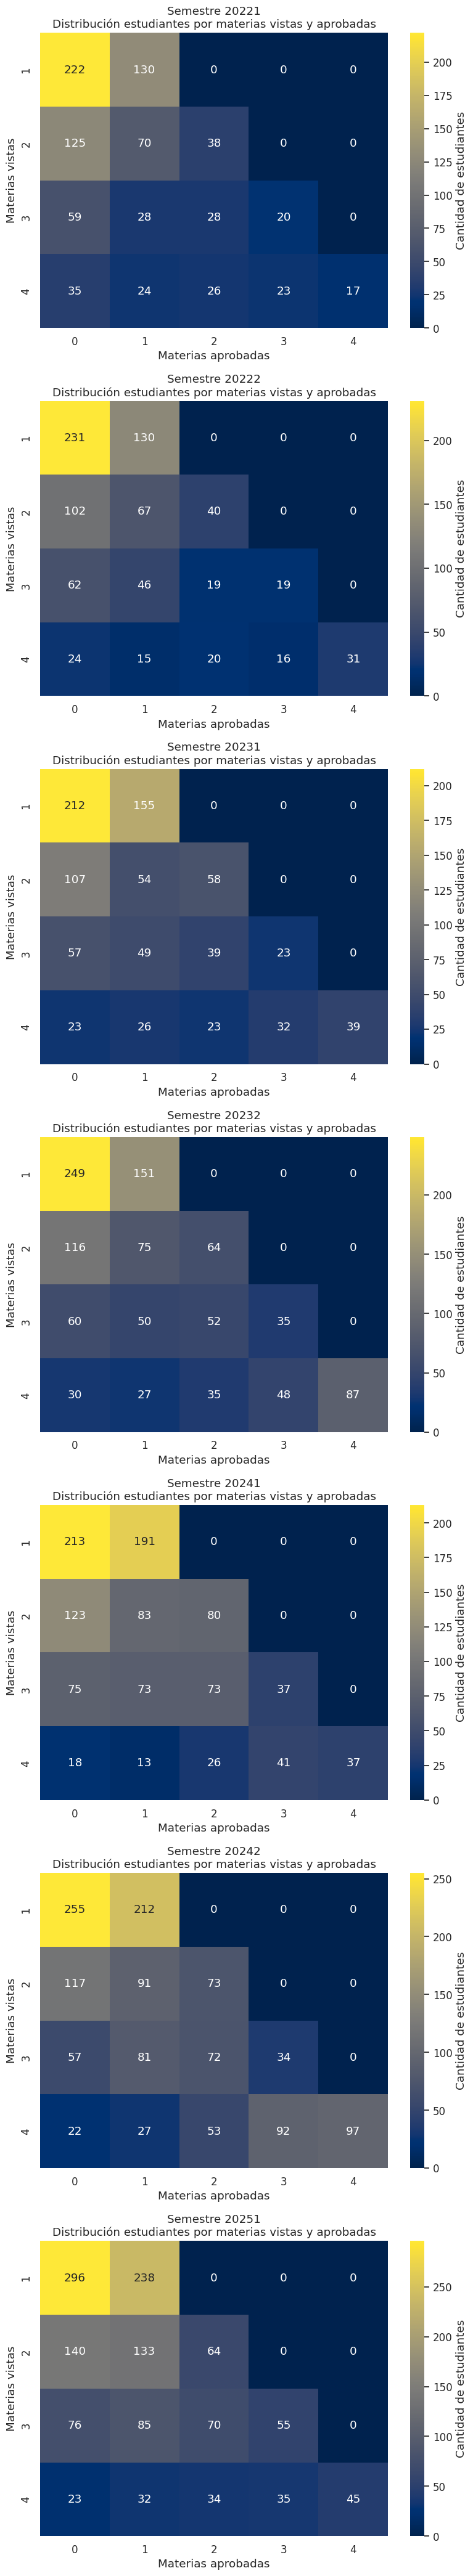

In [4]:
semestres = sorted(por_estudiante['Orden_Cronologico'].unique())
n_sem     = len(semestres)

fig, axes = plt.subplots(n_sem, 1, figsize=(8, 6 * n_sem))
if n_sem == 1:
    axes = [axes]

for ax, sem in zip(axes, semestres):
    df_sem = por_estudiante[por_estudiante['Orden_Cronologico'] == sem]
    tabla  = pd.crosstab(df_sem['Materias_Vistas'], df_sem['Materias_Aprobadas'])

    sns.heatmap(
        tabla, annot=True, fmt='d', cmap='cividis',
        cbar_kws={'label': 'Cantidad de estudiantes'}, ax=ax,
    )
    ax.set_title(f'Semestre {sem}\nDistribución estudiantes por materias vistas y aprobadas')
    ax.set_xlabel('Materias aprobadas')
    ax.set_ylabel('Materias vistas')

plt.tight_layout()
plt.show()


### 4b. Fig. 1 (paper) — Semestre 2022-1
Figura publicada en el paper: distribución de estudiantes según materias
cursadas y aprobadas en el primer semestre de observación (2022-1).

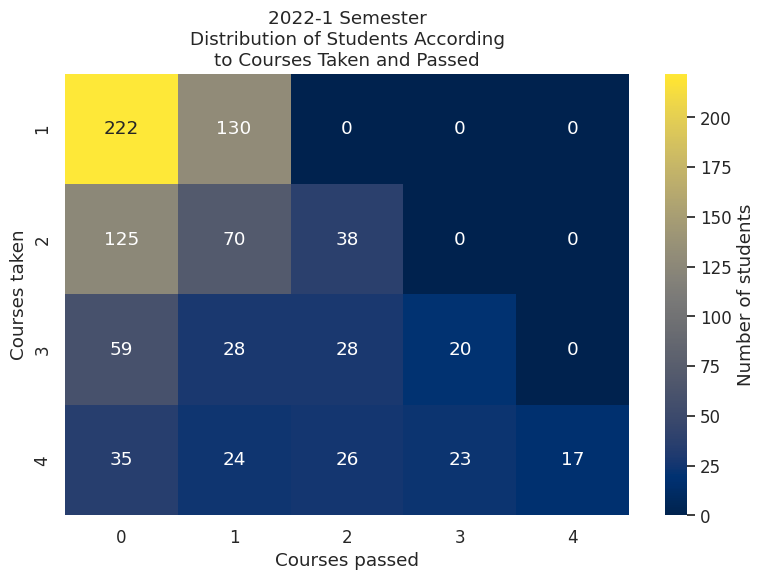

In [5]:
SEMESTRE_PAPER = 20221   # 2022-1 en formato YYYYS

df_sem_paper = por_estudiante[por_estudiante['Orden_Cronologico'] == SEMESTRE_PAPER]
tabla_paper  = pd.crosstab(df_sem_paper['Materias_Vistas'], df_sem_paper['Materias_Aprobadas'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    tabla_paper,
    annot=True, fmt='d', cmap='cividis',
    cbar_kws={'label': 'Number of students'},
)
plt.title('2022-1 Semester\nDistribution of Students According\nto Courses Taken and Passed')
plt.xlabel('Courses passed')
plt.ylabel('Courses taken')
plt.tight_layout()
plt.show()


## 5. Tasa de aprobación acumulada
Se define la tasa de aprobación de cada estudiante como:

$$\text{Tasa de aprobación} = \frac{\text{Total de materias aprobadas}}{\text{Total de materias intentadas}}$$

Este indicador acumula todos los intentos a lo largo del período observado.

In [6]:
# Excluir registros pendientes (Permanencia == 2) para el modelado
trayectorias_modelo = trayectorias[trayectorias['Permanencia'] != 2].copy()
print(f'Registros para modelado (excl. pendientes): {len(trayectorias_modelo):,}')

# Tasa de aprobación global por estudiante
rendimiento = (
    trayectorias_modelo
    .groupby('Documento')
    .agg(Tasa_aprobacion=(
        'Resultados_num',
        lambda x: sum(sum(lst) for lst in x) / sum(len(lst) for lst in x)
    ))
)

# Unir con la variable de permanencia
perm_por_est = (
    trayectorias_modelo[['Documento', 'Permanencia']]
    .drop_duplicates('Documento')
)
datos = rendimiento.merge(perm_por_est, on='Documento')

print('\nEstadísticos de Tasa de aprobación por grupo de Permanencia:')
print(datos.groupby('Permanencia')['Tasa_aprobacion'].describe().round(3))


Registros para modelado (excl. pendientes): 6,305

Estadísticos de Tasa de aprobación por grupo de Permanencia:
              count   mean    std    min    25%  50%   75%   max
Permanencia                                                     
0             838.0  0.132  0.208  0.000  0.000  0.0  0.25  0.75
1            1315.0  0.805  0.225  0.167  0.667  1.0  1.00  1.00


## 6. Exploración — Relación tasa de aprobación vs. permanencia (Boxplot)
Gráfica exploratoria que complementa el análisis antes del modelado.
No incluida en el paper publicado.

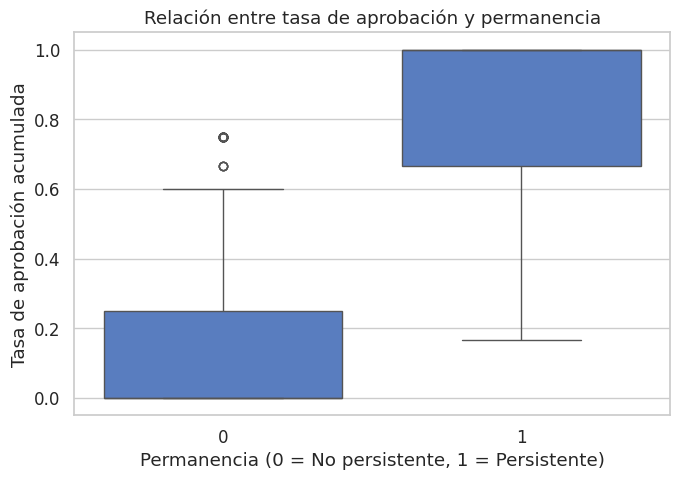

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=datos, x='Permanencia', y='Tasa_aprobacion')
plt.title('Relación entre tasa de aprobación y permanencia')
plt.xlabel('Permanencia (0 = No persistente, 1 = Persistente)')
plt.ylabel('Tasa de aprobación acumulada')
plt.tight_layout()
plt.show()


## 7. Fig. 2 — Modelo de Regresión Logística
Se entrena un modelo de regresión logística con la tasa de aprobación
como único predictor y `Permanencia` (0/1) como variable respuesta.

**Configuración del modelo:**
- Partición: 70 % entrenamiento / 30 % prueba (`random_state=42`)
- Algoritmo: Logistic Regression (sklearn)

> ⚠️ No modificar `random_state` ni `test_size` — cambia los resultados del paper.

In [8]:
X = datos[['Tasa_aprobacion']]
y = datos['Permanencia']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

print('=== Reporte de clasificación (conjunto de prueba) ===')
print(classification_report(y_test, modelo.predict(X_test)))


=== Reporte de clasificación (conjunto de prueba) ===
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       243
           1       0.89      0.97      0.93       403

    accuracy                           0.91       646
   macro avg       0.92      0.89      0.90       646
weighted avg       0.91      0.91      0.91       646



/sessions/trusting-laughing-brahmagupta/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


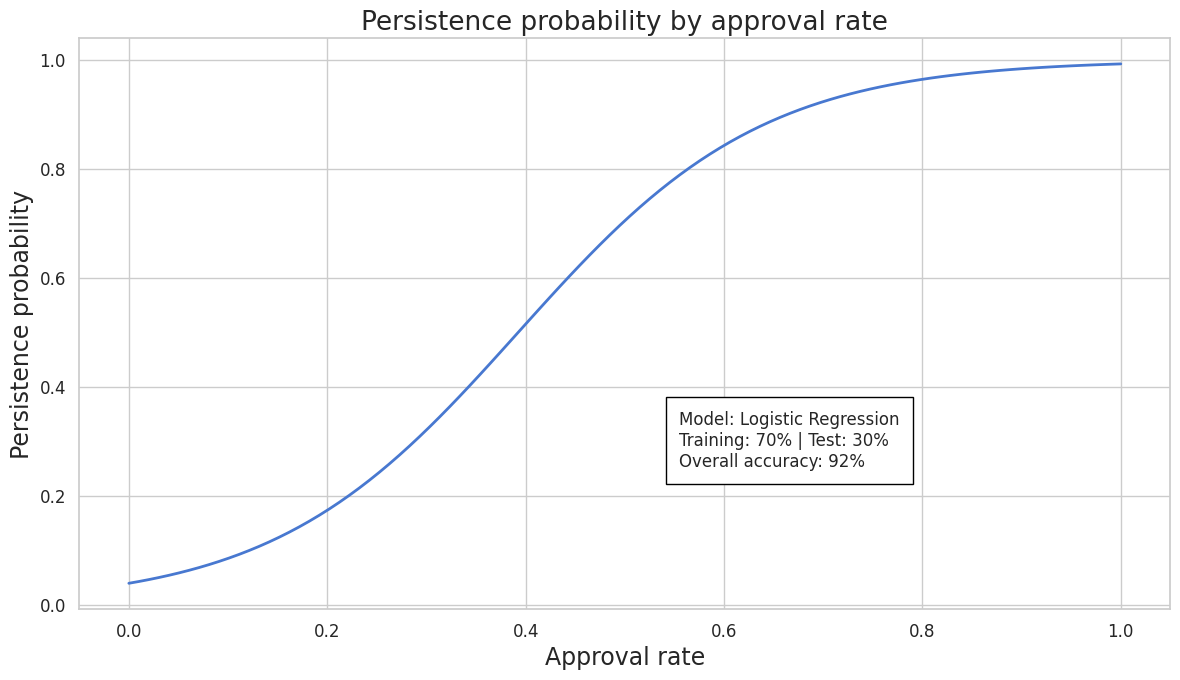

In [9]:
# ── Curva de probabilidad de permanencia (Fig. 2 del paper) ──────────────────
tasa_vals     = np.linspace(0, 1, 100).reshape(-1, 1)
probabilidades = modelo.predict_proba(tasa_vals)[:, 1]

plt.figure(figsize=(12, 7))
plt.plot(tasa_vals, probabilidades, linewidth=2)

plt.xlabel('Approval rate', fontsize=17)
plt.ylabel('Persistence probability', fontsize=17)
plt.title('Persistence probability by approval rate', fontsize=19)

# Cuadro informativo (igual al paper)
plt.text(
    0.55, 0.25,
    'Model: Logistic Regression\n'
    'Training: 70% | Test: 30%\n'
    'Overall accuracy: 92%',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle='square,pad=0.8', facecolor='white', edgecolor='black', linewidth=1),
)

plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Predicción de ejemplo: estudiante con tasa 0.6
nuevo = pd.DataFrame({'Tasa_aprobacion': [0.6]})
pred  = modelo.predict(nuevo)[0]
prob  = modelo.predict_proba(nuevo)[0]

print(f'Tasa de aprobación = 0.60')
print(f'  Predicción de permanencia : {pred}')
print(f'  P(No persiste)            : {prob[0]:.4f}')
print(f'  P(Sí persiste)            : {prob[1]:.4f}')


Tasa de aprobación = 0.60
  Predicción de permanencia : 1
  P(No persiste)            : 0.1569
  P(Sí persiste)            : 0.8431


## 8. Análisis de correlación carga-rendimiento por estudiante
Para cada estudiante con registros en ≥ 2 semestres se calcula la correlación
de Pearson entre:
- **Carga semestral**: número de materias matriculadas
- **Tasa de aprobación semestral**: proporción de materias aprobadas en ese semestre

In [11]:
# Tasa de aprobación por semestre (no acumulada)
por_estudiante['Tasa_aprobacion_semestre'] = (
    por_estudiante['Materias_Aprobadas'] / por_estudiante['Materias_Vistas']
)

# Correlación individual: carga vs. tasa semestral
corrs_list = [
    {'Documento': doc, 'Correlacion_Carga_Rendimiento': grp['Materias_Vistas'].corr(grp['Tasa_aprobacion_semestre'])}
    for doc, grp in por_estudiante.groupby('Documento')
    if len(grp) >= 2
]
corrs = pd.DataFrame(corrs_list)

print(f'Estudiantes con ≥ 2 semestres registrados: {len(corrs):,}')
corrs['Correlacion_Carga_Rendimiento'].describe().round(3)


/usr/local/lib/python3.10/dist-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Estudiantes con ≥ 2 semestres registrados: 2,131


count    1386.000
mean       -0.093
std         0.833
min        -1.000
25%        -1.000
50%        -0.079
75%         0.866
max         1.000
Name: Correlacion_Carga_Rendimiento, dtype: float64

## 9. Clasificación de perfiles estudiantiles (Tabla I)
Se asigna a cada estudiante un perfil de respuesta según su correlación:
- **Sobrecarga** (r < −0.5): a mayor carga, peor rendimiento
- **Independiente** (−0.5 ≤ r ≤ 0.5): sin relación clara
- **Mejor con carga** (r > 0.5): a mayor carga, mejor rendimiento

In [12]:
# Clasificación por umbrales
corrs['Tipo'] = np.select(
    [
        corrs['Correlacion_Carga_Rendimiento'] < -0.5,
        corrs['Correlacion_Carga_Rendimiento'].between(-0.5, 0.5),
        corrs['Correlacion_Carga_Rendimiento'] > 0.5,
    ],
    ['Sobrecarga', 'Independiente', 'Mejor con carga'],
    default='Sin datos',
)

# Unir con tasa global y marcar bajo rendimiento
corrs = corrs.merge(rendimiento, on='Documento', how='left')
corrs['Bajo_Rendimiento_Global'] = corrs['Tasa_aprobacion'] < 0.5

# ── Tabla I (paper) ───────────────────────────────────────────────────────────
tabla_i = (
    corrs.groupby('Tipo')
    .agg(
        Total             = ('Documento', 'count'),
        Bajo_Rendimiento  = ('Bajo_Rendimiento_Global', 'sum'),
    )
    .reset_index()
)
tabla_i['Proporcion_Bajo_Rendimiento'] = (
    tabla_i['Bajo_Rendimiento'] / tabla_i['Total']
).round(2)

print('=== Tabla I — Distribución de perfiles y proporción de bajo rendimiento ===')
print(tabla_i.to_string(index=False))


=== Tabla I — Distribución de perfiles y proporción de bajo rendimiento ===
           Tipo  Total  Bajo_Rendimiento  Proporcion_Bajo_Rendimiento
  Independiente    316                90                         0.28
Mejor con carga    463               121                         0.26
      Sin datos    745               286                         0.38
     Sobrecarga    607                48                         0.08


## 10. Fig. 3 — Distribución de correlaciones carga-rendimiento
Histograma de los coeficientes de correlación individuales con las
líneas de umbral de clasificación de perfiles.

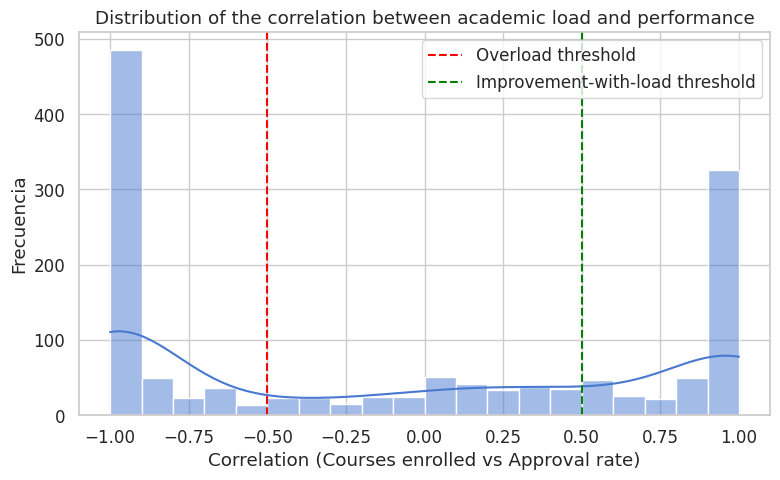

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(corrs['Correlacion_Carga_Rendimiento'], kde=True, bins=20)

plt.title('Distribution of the correlation between academic load and performance')
plt.xlabel('Correlation (Courses enrolled vs Approval rate)')
plt.ylabel('Frecuencia')

plt.axvline(-0.5, color='red',   linestyle='--', label='Overload threshold')
plt.axvline( 0.5, color='green', linestyle='--', label='Improvement-with-load threshold')

plt.legend()
plt.tight_layout()
plt.show()


## 11. Relación entre perfiles de carga-rendimiento y permanencia
Se contrasta cada perfil con la variable de Permanencia para identificar
patrones diferenciados de persistencia institucional.

=== Proporción de permanencia por perfil ===
           Tipo  Total  Permanentes  Proporcion_Permanentes
  Independiente    316          121                    0.38
Mejor con carga    463           37                    0.08
      Sin datos    745          244                    0.33
     Sobrecarga    607          369                    0.61


/sessions/trusting-laughing-brahmagupta/tmp/ipykernel_8/2771753956.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


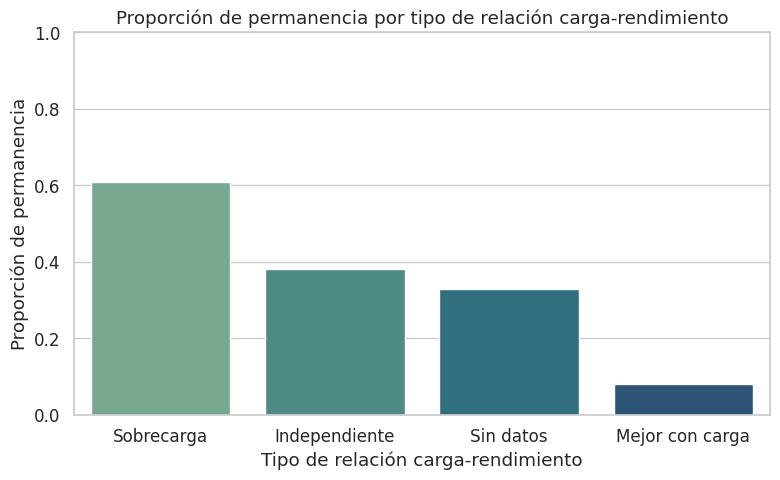

In [14]:
corrs_perm = corrs.merge(
    trayectorias_modelo[['Documento', 'Permanencia']].drop_duplicates('Documento'),
    on='Documento', how='left',
)

resumen_perm = (
    corrs_perm.groupby('Tipo')
    .agg(
        Total       = ('Documento', 'count'),
        Permanentes = ('Permanencia', lambda x: (x == 1).sum()),
    )
    .reset_index()
)
resumen_perm['Proporcion_Permanentes'] = (
    resumen_perm['Permanentes'] / resumen_perm['Total']
).round(2)

print('=== Proporción de permanencia por perfil ===')
print(resumen_perm.to_string(index=False))

# Gráfica comparativa
plt.figure(figsize=(8, 5))
sns.barplot(
    data=resumen_perm.sort_values('Proporcion_Permanentes', ascending=False),
    x='Tipo', y='Proporcion_Permanentes', palette='crest',
)
plt.title('Proporción de permanencia por tipo de relación carga-rendimiento')
plt.ylabel('Proporción de permanencia')
plt.xlabel('Tipo de relación carga-rendimiento')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 12. Comparación de aprobación media por grupo de permanencia

In [15]:
trayectorias_modelo['Aprobadas_sem'] = trayectorias_modelo['Resultados_num'].apply(
    lambda x: sum(x) if isinstance(x, list) else ast.literal_eval(x)
)

comparacion = (
    trayectorias_modelo.groupby('Permanencia')
    .agg(Aprobadas_sem_media=('Aprobadas_sem', 'mean'))
    .round(3)
)
print(comparacion)


             Aprobadas_sem_media
Permanencia                     
0                          0.256
1                          1.000
